# 03 — Model Training

## Behavioral Reputation-Based Fake Review Detection Using Machine Learning

This notebook trains baseline machine learning models using the final processed behavioral and reviewer reputation features.

Models covered:
- Logistic Regression
- Random Forest

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
train_df = pd.read_csv("../data/processed/train_processed.csv")
test_df = pd.read_csv("../data/processed/test_processed.csv")

print("Training data shape:", train_df.shape)
print("Test data shape:", test_df.shape)

Training data shape: (9929, 19)
Test data shape: (2483, 19)


In [3]:
train_df.head()

,rating,restaurantRating,rating_deviation,friendCount,reviewCount,reviewUsefulCount,usefulCount,coolCount,funnyCount,complimentCount,tipCount,fanCount,reviewer_account_age_days,reviewer_engagement_ratio,reviewer_social_reach,reviewer_helpfulness_ratio,reviewer_activity_level,review_word_count,flagged
0,5,4.0,1.0,0,1,0,1,2,0,0,0,0,443,1.500000,0,0.500000,0.693147,144,1
1,5,4.0,1.0,5,12,0,19,7,6,4,0,0,30,2.461538,5,1.461538,2.564949,46,0
2,5,3.5,1.5,0,6,0,7,3,2,0,0,0,30,1.714286,0,1.000000,1.945910,18,1
3,5,3.5,1.5,2,37,0,16,3,3,1,0,1,56,0.578947,3,0.421053,3.637586,41,0
4,5,4.0,1.0,0,3,0,2,1,0,0,0,0,280,0.750000,0,0.500000,1.386294,40,1


In [4]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9929 entries, 0 to 9928
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   rating                      9929 non-null   int64  
 1   restaurantRating            9929 non-null   float64
 2   rating_deviation            9929 non-null   float64
 3   friendCount                 9929 non-null   int64  
 4   reviewCount                 9929 non-null   int64  
 5   reviewUsefulCount           9929 non-null   int64  
 6   usefulCount                 9929 non-null   int64  
 7   coolCount                   9929 non-null   int64  
 8   funnyCount                  9929 non-null   int64  
 9   complimentCount             9929 non-null   int64  
 10  tipCount                    9929 non-null   int64  
 11  fanCount                    9929 non-null   int64  
 12  reviewer_account_age_days   9929 non-null   int64  
 13  reviewer_engagement_ratio   9929 non-null   

In [5]:
train_df.isnull().sum()

rating                        0
restaurantRating              0
rating_deviation              0
friendCount                   0
reviewCount                   0
reviewUsefulCount             0
usefulCount                   0
coolCount                     0
funnyCount                    0
complimentCount               0
tipCount                      0
fanCount                      0
reviewer_account_age_days     0
reviewer_engagement_ratio     0
reviewer_social_reach         0
reviewer_helpfulness_ratio    0
reviewer_activity_level       0
review_word_count             0
flagged                       0
dtype: int64

In [6]:
target_col = "flagged"

X = train_df.drop(columns=[target_col])
y = train_df[target_col]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (9929, 18)
Target shape: (9929,)


In [7]:
y.value_counts(normalize=True)

flagged
0    0.502971
1    0.497029
Name: proportion, dtype: float64

In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (7943, 18)
X_val: (1986, 18)
y_train: (7943,)
y_val: (1986,)


In [9]:
def evaluate_model(model, X_val, y_val, model_name):
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]

    print(f"========== {model_name} ==========")
    print("Accuracy :", accuracy_score(y_val, y_pred))
    print("Precision:", precision_score(y_val, y_pred))
    print("Recall   :", recall_score(y_val, y_pred))
    print("F1-score :", f1_score(y_val, y_pred))
    print("ROC-AUC  :", roc_auc_score(y_val, y_proba))

    print("\nClassification Report:")
    print(classification_report(y_val, y_pred))

    cm = confusion_matrix(y_val, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [10]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

========== Logistic Regression ==========
Accuracy : 0.8554884189325277
Precision: 0.8365384615384616
Recall   : 0.8814589665653495
F1-score : 0.8584114454859398
ROC-AUC  : 0.9318639815093717

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.83      0.85       999
           1       0.84      0.88      0.86       987

    accuracy                           0.86      1986
   macro avg       0.86      0.86      0.86      1986
weighted avg       0.86      0.86      0.86      1986



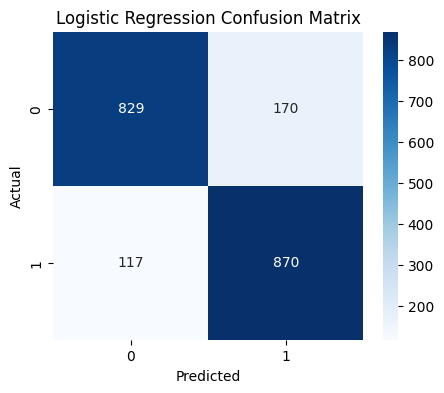

In [11]:
evaluate_model(
    logistic_model,
    X_val,
    y_val,
    "Logistic Regression"
)

In [12]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

========== Random Forest ==========
Accuracy : 0.8856998992950654
Precision: 0.87109375
Recall   : 0.9037487335359676
F1-score : 0.887120835405271
ROC-AUC  : 0.9555005867062605

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.87      0.88       999
           1       0.87      0.90      0.89       987

    accuracy                           0.89      1986
   macro avg       0.89      0.89      0.89      1986
weighted avg       0.89      0.89      0.89      1986



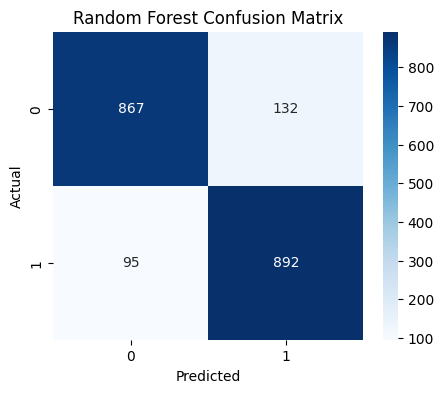

In [13]:
evaluate_model(
    random_forest_model,
    X_val,
    y_val,
    "Random Forest"
)

In [14]:
models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1-score": f1_score(y_val, y_pred),
        "ROC-AUC": roc_auc_score(y_val, y_proba)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.855488,0.836538,0.881459,0.858411,0.931864
1,Random Forest,0.885700,0.871094,0.903749,0.887121,0.955501


In [15]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
6,usefulCount,0.153375
4,reviewCount,0.111435
12,reviewer_account_age_days,0.092468
16,reviewer_activity_level,0.089952
14,reviewer_social_reach,0.089469
7,coolCount,0.064764
3,friendCount,0.064673
5,reviewUsefulCount,0.058754
17,review_word_count,0.055814
8,funnyCount,0.041130


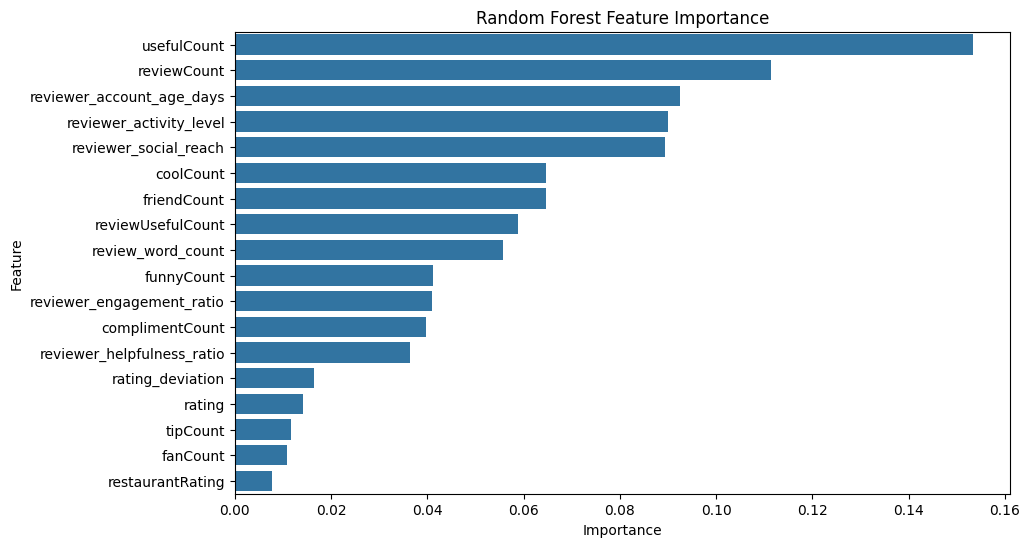

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x="Importance", y="Feature")
plt.title("Random Forest Feature Importance")
plt.show()

In [17]:
logistic_coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logistic_model.named_steps["model"].coef_[0]
}).sort_values(by="Coefficient", ascending=False)

logistic_coefficients

,Feature,Coefficient
2,rating_deviation,0.273458
3,friendCount,0.267145
4,reviewCount,0.162113
14,reviewer_social_reach,0.025129
0,rating,-0.017608
9,complimentCount,-0.025756
1,restaurantRating,-0.039290
13,reviewer_engagement_ratio,-0.086742
15,reviewer_helpfulness_ratio,-0.203330
17,review_word_count,-0.223584


In [18]:
final_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

final_model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [19]:
X_test = test_df.copy()

print("External test shape:", X_test.shape)

External test shape: (2483, 19)


========== Final Random Forest on External Test ==========
Accuracy : 0.8888441401530407
Precision: 0.8743416102332581
Recall   : 0.9142407553107789
F1-score : 0.8938461538461538
ROC-AUC  : 0.948087639212387

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.86      0.88      1212
           1       0.87      0.91      0.89      1271

    accuracy                           0.89      2483
   macro avg       0.89      0.89      0.89      2483
weighted avg       0.89      0.89      0.89      2483



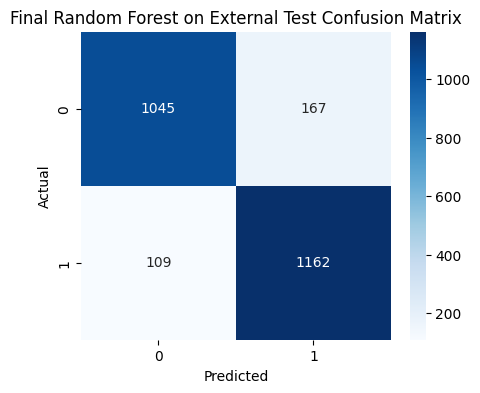

In [20]:
if "flagged" in test_df.columns:
    X_test = test_df.drop(columns=["flagged"])
    y_test = test_df["flagged"]

    evaluate_model(final_model, X_test, y_test, "Final Random Forest on External Test")
else:
    test_predictions = final_model.predict(X_test)
    test_probabilities = final_model.predict_proba(X_test)[:, 1]

    predictions_df = test_df.copy()
    predictions_df["predicted_flagged"] = test_predictions
    predictions_df["fraud_probability"] = test_probabilities

    predictions_df.head()

In [21]:
if "flagged" not in test_df.columns:
    predictions_df.to_csv("../data/processed/test_predictions.csv", index=False)
    print("Predictions saved successfully.")

In [22]:
import joblib

joblib.dump(final_model, "../models/random_forest_model.pkl")

print("Model saved successfully.")

Model saved successfully.
